# Reddit Signal Modeling Notebook

Goal: build a calibrated daily volatility-regime signal from LLM-labeled Reddit data for downstream sentiment-agent fusion.

## Problem Framing

Task: supervised binary classification of next-day FX volatility regime using Reddit-derived daily features.

Temporal constraint: strict forward-looking setup with TimeSeriesSplit only.

Primary metric: ROC-AUC; secondary metrics: macro-F1 and balanced accuracy.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
print("Libraries loaded")

Libraries loaded


In [2]:
DATA_PATH = Path(r"D:/SCRIPTS/FX-AlphaLab/data/processed/REDDIT MEDIA/reddit_labels_checkpoint.jsonl")
raw_df = pd.read_json(DATA_PATH, lines=True)
raw_df["created_dt"] = pd.to_datetime(raw_df["created_utc"], unit="s", utc=True)
raw_df["date"] = raw_df["created_dt"].dt.floor("D")

print("Raw shape:", raw_df.shape)
print("Date range:", raw_df["date"].min(), "->", raw_df["date"].max())
display(raw_df[["id", "content_type", "stance_clarity", "target_pair", "score", "risk_sentiment"]].head(5))

Raw shape: (25458, 18)
Date range: 2021-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00


,id,content_type,stance_clarity,target_pair,score,risk_sentiment
0,1dg08oi,NOISE,QUESTION,None,0,NEUTRAL
1,1k6d22q,FUNDAMENTAL,QUESTION,None,18,NEUTRAL
2,wg0mpf,NOISE,QUESTION,None,0,NEUTRAL
3,1d0b4rg,NOISE,NONE,None,0,NEUTRAL
4,1kziloy,NOISE,NONE,None,2,NEUTRAL


from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 200)
print("Libraries loaded")

In [3]:
# Stage 1.1 + 1.2: ordered filters
allowed_content = {"FUNDAMENTAL", "NEWS_REACTION", "TECHNICAL", "POSITION_DISCLOSURE"}

raw_daily_counts = raw_df.groupby("date").size().rename("raw_post_count").reset_index()

s1 = raw_df[raw_df["content_type"].isin(allowed_content)].copy()
s2 = s1[s1["stance_clarity"] != "QUESTION"].copy()

print("Rows after content filter:", len(s1), f"({len(s1)/len(raw_df):.2%})")
print("Rows after stance filter:", len(s2), f"({len(s2)/len(raw_df):.2%})")

display(s2[["content_type", "stance_clarity", "risk_sentiment", "target_pair", "score"]].head(5))

Rows after content filter: 6161 (24.20%)
Rows after stance filter: 3449 (13.55%)


,content_type,stance_clarity,risk_sentiment,target_pair,score
5,TECHNICAL,CLEAR,RISK_OFF,None,0
6,NEWS_REACTION,NONE,RISK_OFF,USD,143
10,FUNDAMENTAL,CLEAR,RISK_ON,None,0
16,TECHNICAL,CLEAR,NEUTRAL,EURUSD,2
18,NEWS_REACTION,CLEAR,NEUTRAL,None,0


In [4]:
# Stage 1.3: pair attribution
pair_list = [
    "EURUSD", "GBPUSD", "USDJPY", "XAUUSD", "AUDUSD",
    "USDCAD", "USDCHF", "NZDUSD", "EURGBP", "EURJPY", "GBPJPY"
]
pair_set = set(pair_list)
pair_pattern = re.compile("|".join(pair_list))

def normalize_existing_pair(x: object) -> str | None:
    if pd.isna(x):
        return None
    txt = str(x).upper()
    txt = re.sub(r"[^A-Z]", "", txt)
    if txt in pair_set:
        return txt
    m = pair_pattern.search(txt)
    return m.group(0) if m else None

def extract_pair_from_text(title: object, body: object) -> str | None:
    txt = f"{title if pd.notna(title) else ''} {body if pd.notna(body) else ''}".upper()
    txt = re.sub(r"[^A-Z]", "", txt)
    m = pair_pattern.search(txt)
    return m.group(0) if m else None

s2["pair"] = s2["target_pair"].apply(normalize_existing_pair)
missing_pair = s2["pair"].isna()
s2.loc[missing_pair, "pair"] = s2.loc[missing_pair].apply(
    lambda r: extract_pair_from_text(r["title"], r["body"]), axis=1
)
s2["pair"] = s2["pair"].fillna("global")

print("Pair attribution distribution (top 12):")
display(s2["pair"].value_counts().head(12))

Pair attribution distribution (top 12):


pair
global    2568
EURUSD     226
XAUUSD     186
GBPUSD     119
USDJPY      89
GBPJPY      71
AUDUSD      48
USDCAD      38
USDCHF      29
NZDUSD      28
EURGBP      25
EURJPY      22
Name: count, dtype: int64

In [5]:
# Stage 1.4 + 1.5 + 1.6: weights
score_clip_p99 = s2["score"].quantile(0.99)
s2["score_clip"] = s2["score"].clip(upper=score_clip_p99)
s2["w_score"] = np.log1p(s2["score_clip"])
content_weight_map = {
    "FUNDAMENTAL": 2,
    "NEWS_REACTION": 2,
    "TECHNICAL": 1,
    "POSITION_DISCLOSURE": 1,
}
s2["w_content"] = s2["content_type"].map(content_weight_map).astype(float)
s2["w"] = s2["w_score"] * s2["w_content"]

print("Score clip p99:", round(score_clip_p99, 3))
print("Weight summary:")
display(s2[["w_score", "w_content", "w"]].describe().T)

Score clip p99: 2166.04
Weight summary:


,count,mean,std,min,25%,50%,75%,max
w_score,3449.0,2.100417,1.833205,0.0,0.693147,1.609438,3.044522,7.681117
w_content,3449.0,1.284140,0.451069,1.0,1.000000,1.000000,2.000000,2.000000
w,3449.0,2.965736,3.480328,0.0,0.693147,1.609438,3.583519,15.362235


**Filtering is aggressive by design and preserves interpretable signal content.**

Only 13.55% of rows remain after removing noise and question-like posts, which is expected for high-precision sentiment extraction.
The pair-attribution step leaves a broad `global` segment plus identifiable major FX pairs.
Next we aggregate into daily global and pair-level features with confidence and fundamental-share diagnostics.

In [7]:
def weighted_mean(x: pd.Series, w: pd.Series) -> float:
    wsum = w.sum()
    if wsum <= 0:
        # If all weights are zero (e.g., all scores == 0), fall back to unweighted mean.
        return float(x.mean())
    return float(np.average(x, weights=w))

s2["risk_off_ind"] = (s2["risk_sentiment"] == "RISK_OFF").astype(float)
s2["risk_on_ind"] = (s2["risk_sentiment"] == "RISK_ON").astype(float)
s2["fundamental_news_ind"] = s2["content_type"].isin(["FUNDAMENTAL", "NEWS_REACTION"]).astype(float)

# Global daily features
global_daily = (
    s2.groupby("date", as_index=False)
      .apply(lambda g: pd.Series({
          "risk_off_score": weighted_mean(g["risk_off_ind"], g["w"]),
          "risk_on_score": weighted_mean(g["risk_on_ind"], g["w"]),
          "sentiment_strength_wmean": weighted_mean(g["sentiment_strength"], g["w"]),
          "signal_post_count": len(g),
          "fundamental_share": g["fundamental_news_ind"].mean(),
      }), include_groups=False)
)

global_daily = global_daily.merge(raw_daily_counts, on="date", how="left")
global_daily["confidence"] = global_daily["signal_post_count"] / global_daily["raw_post_count"]

# Pair-level daily features
pair_daily = (
    s2.groupby(["date", "pair"], as_index=False)
      .apply(lambda g: pd.Series({
          "risk_off_score": weighted_mean(g["risk_off_ind"], g["w"]),
          "risk_on_score": weighted_mean(g["risk_on_ind"], g["w"]),
          "sentiment_strength_wmean": weighted_mean(g["sentiment_strength"], g["w"]),
          "signal_post_count": len(g),
          "fundamental_share": g["fundamental_news_ind"].mean(),
      }), include_groups=False)
)

pair_daily = pair_daily.merge(raw_daily_counts, on="date", how="left")
pair_daily["confidence"] = pair_daily["signal_post_count"] / pair_daily["raw_post_count"]

print("Global daily shape:", global_daily.shape)
print("Pair daily shape:", pair_daily.shape)
print("Global daily null check:")
print(global_daily[["risk_off_score", "risk_on_score", "sentiment_strength_wmean"]].isna().sum())
display(global_daily.head(5))

Global daily shape: (1358, 8)
Pair daily shape: (2011, 9)
Global daily null check:
risk_off_score              0
risk_on_score               0
sentiment_strength_wmean    0
dtype: int64


,date,risk_off_score,risk_on_score,sentiment_strength_wmean,signal_post_count,fundamental_share,raw_post_count,confidence
0,2021-01-01 00:00:00+00:00,0.00000,0.000000,0.375804,2.0,0.000000,11,0.181818
1,2021-01-02 00:00:00+00:00,0.00000,0.000000,0.000000,1.0,0.000000,17,0.058824
2,2021-01-03 00:00:00+00:00,0.00000,0.410051,-0.769847,3.0,0.333333,9,0.333333
3,2021-01-04 00:00:00+00:00,0.00000,0.000000,-2.000000,3.0,0.666667,22,0.136364
4,2021-01-05 00:00:00+00:00,0.56058,0.000000,-1.121159,6.0,0.500000,21,0.285714


Risk-off score distribution by half-life:


,half_life_days,mean,std,p25,median,p75,p95,zero_days
0,3,0.196191,0.200802,0.025925,0.129336,0.315605,0.593776,274
1,5,0.199775,0.188605,0.034763,0.155854,0.313219,0.576552,274
2,7,0.200922,0.184366,0.039290,0.163561,0.313431,0.566212,274


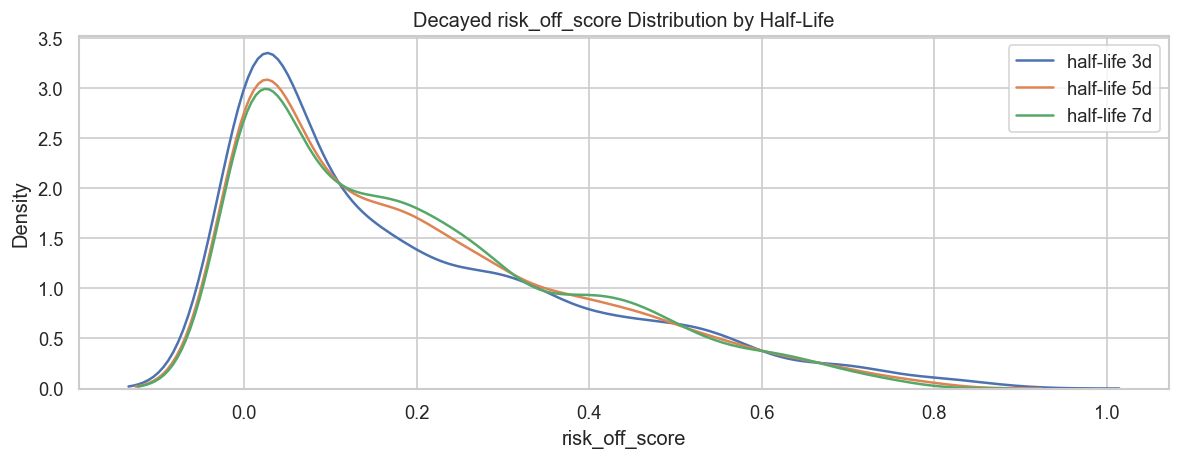

Chosen half-life days: 5
Global daily shape: (1826, 9)
Pair daily shape: (20086, 10)


,date,raw_post_count,signal_post_count,risk_off_score,risk_on_score,sentiment_strength_wmean,fundamental_share,confidence,half_life_days
0,2021-01-01 00:00:00+00:00,11,3.688879,0.000000,0.000000,0.375804,0.000000,0.335353,5
1,2021-01-02 00:00:00+00:00,17,3.211356,0.000000,0.000000,0.375804,0.000000,0.188903,5
2,2021-01-03 00:00:00+00:00,9,9.557221,0.000000,0.290104,-0.434725,0.290104,1.061913,5
3,2021-01-04 00:00:00+00:00,22,10.111803,0.000000,0.238699,-0.712084,0.238699,0.459627,5
4,2021-01-05 00:00:00+00:00,21,30.231921,0.397352,0.069504,-1.002046,0.604421,1.439615,5


In [8]:
def build_decayed_tables(posts: pd.DataFrame, half_life_days: int, calendar_days: pd.DataFrame, pair_values: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build full daily global and pair-level tables using exponential decay."""
    lambda_ = np.log(2) / half_life_days
    decay_window_days = 14
    decay_offsets = np.arange(decay_window_days)

    base_cols = [
        "date",
        "pair",
        "w",
        "risk_off_ind",
        "risk_on_ind",
        "sentiment_strength",
        "fundamental_news_ind",
    ]
    base = posts[base_cols].copy()

    expanded_frames = []
    for offset in decay_offsets:
        temp = base.copy()
        temp["date"] = temp["date"] + pd.to_timedelta(offset, unit="D")
        decay = float(np.exp(-lambda_ * offset))
        temp["effective_weight"] = temp["w"] * decay
        temp["risk_off_num"] = temp["effective_weight"] * temp["risk_off_ind"]
        temp["risk_on_num"] = temp["effective_weight"] * temp["risk_on_ind"]
        temp["sentiment_num"] = temp["effective_weight"] * temp["sentiment_strength"]
        temp["fundamental_num"] = temp["effective_weight"] * temp["fundamental_news_ind"]
        expanded_frames.append(temp[["date", "pair", "effective_weight", "risk_off_num", "risk_on_num", "sentiment_num", "fundamental_num"]])

    expanded = pd.concat(expanded_frames, ignore_index=True)

    global_agg = (
        expanded.groupby("date", as_index=False)
        .sum(numeric_only=True)
        .rename(columns={"effective_weight": "signal_post_count"})
    )
    global_daily = calendar_days.merge(global_agg, on="date", how="left")

    pair_posts = posts[posts["pair"] != "global"].copy()
    pair_base = pair_posts[base_cols].copy()
    pair_frames = []
    for offset in decay_offsets:
        temp = pair_base.copy()
        temp["date"] = temp["date"] + pd.to_timedelta(offset, unit="D")
        decay = float(np.exp(-lambda_ * offset))
        temp["effective_weight"] = temp["w"] * decay
        temp["risk_off_num"] = temp["effective_weight"] * temp["risk_off_ind"]
        temp["risk_on_num"] = temp["effective_weight"] * temp["risk_on_ind"]
        temp["sentiment_num"] = temp["effective_weight"] * temp["sentiment_strength"]
        temp["fundamental_num"] = temp["effective_weight"] * temp["fundamental_news_ind"]
        pair_frames.append(temp[["date", "pair", "effective_weight", "risk_off_num", "risk_on_num", "sentiment_num", "fundamental_num"]])

    pair_expanded = pd.concat(pair_frames, ignore_index=True)
    pair_agg = (
        pair_expanded.groupby(["date", "pair"], as_index=False)
        .sum(numeric_only=True)
        .rename(columns={"effective_weight": "signal_post_count"})
    )
    pair_grid = calendar_days.assign(_key=1).merge(
        pd.DataFrame({"pair": pair_values, "_key": 1}),
        on="_key",
        how="outer",
    ).drop(columns="_key")
    pair_daily = pair_grid.merge(pair_agg, on=["date", "pair"], how="left")

    for table in (global_daily, pair_daily):
        table["raw_post_count"] = table["date"].map(calendar_days.set_index("date")["raw_post_count"])
        table[["signal_post_count", "risk_off_num", "risk_on_num", "sentiment_num", "fundamental_num"]] = table[["signal_post_count", "risk_off_num", "risk_on_num", "sentiment_num", "fundamental_num"]].fillna(0.0)
        table["risk_off_score"] = np.divide(
            table["risk_off_num"],
            table["signal_post_count"],
            out=np.zeros(len(table), dtype=float),
            where=table["signal_post_count"] > 0,
        )
        table["risk_on_score"] = np.divide(
            table["risk_on_num"],
            table["signal_post_count"],
            out=np.zeros(len(table), dtype=float),
            where=table["signal_post_count"] > 0,
        )
        table["sentiment_strength_wmean"] = np.divide(
            table["sentiment_num"],
            table["signal_post_count"],
            out=np.zeros(len(table), dtype=float),
            where=table["signal_post_count"] > 0,
        )
        table["fundamental_share"] = np.divide(
            table["fundamental_num"],
            table["signal_post_count"],
            out=np.zeros(len(table), dtype=float),
            where=table["signal_post_count"] > 0,
        )
        table["confidence"] = np.divide(
            table["signal_post_count"],
            table["raw_post_count"],
            out=np.zeros(len(table), dtype=float),
            where=table["raw_post_count"] > 0,
        )
        table["half_life_days"] = half_life_days

    global_daily = global_daily[[
        "date",
        "raw_post_count",
        "signal_post_count",
        "risk_off_score",
        "risk_on_score",
        "sentiment_strength_wmean",
        "fundamental_share",
        "confidence",
        "half_life_days",
    ]].sort_values("date").reset_index(drop=True)

    pair_daily = pair_daily[[
        "date",
        "pair",
        "raw_post_count",
        "signal_post_count",
        "risk_off_score",
        "risk_on_score",
        "sentiment_strength_wmean",
        "fundamental_share",
        "confidence",
        "half_life_days",
    ]].sort_values(["date", "pair"]).reset_index(drop=True)

    return global_daily, pair_daily

calendar_days = pd.DataFrame({"date": pd.date_range(raw_df["date"].min(), raw_df["date"].max(), freq="D", tz="UTC")})
calendar_days["raw_post_count"] = calendar_days["date"].map(raw_daily_counts.set_index("date")["raw_post_count"]).fillna(0).astype(int)
pair_values = sorted(p for p in s2["pair"].unique() if p != "global")

half_life_candidates = [3, 5, 7]
decay_tables = {}
comparison_rows = []
for hl in half_life_candidates:
    g_tbl, p_tbl = build_decayed_tables(s2, hl, calendar_days.copy(), pair_values)
    decay_tables[hl] = {"global_daily": g_tbl, "pair_daily": p_tbl}
    comparison_rows.append({
        "half_life_days": hl,
        "mean": g_tbl["risk_off_score"].mean(),
        "std": g_tbl["risk_off_score"].std(),
        "p25": g_tbl["risk_off_score"].quantile(0.25),
        "median": g_tbl["risk_off_score"].median(),
        "p75": g_tbl["risk_off_score"].quantile(0.75),
        "p95": g_tbl["risk_off_score"].quantile(0.95),
        "zero_days": int((g_tbl["risk_off_score"] == 0).sum()),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("half_life_days")
print("Risk-off score distribution by half-life:")
display(comparison_df)

fig, ax = plt.subplots(figsize=(10, 4))
for hl in half_life_candidates:
    sns.kdeplot(decay_tables[hl]["global_daily"]["risk_off_score"], ax=ax, label=f"half-life {hl}d")
ax.set_title("Decayed risk_off_score Distribution by Half-Life")
ax.set_xlabel("risk_off_score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

chosen_half_life_days = 5
global_daily = decay_tables[chosen_half_life_days]["global_daily"].copy()
pair_daily = decay_tables[chosen_half_life_days]["pair_daily"].copy()
print("Chosen half-life days:", chosen_half_life_days)
print("Global daily shape:", global_daily.shape)
print("Pair daily shape:", pair_daily.shape)
display(global_daily.head(5))

**Filtering materially sharpens risk-off intensity.**

The post-filter distribution is much wider and right-tailed versus the pre-filter baseline, showing that irrelevant rows had diluted risk signals.
This is the desired behavior before supervised training because target-relevant variation is amplified.

In [9]:
# Stage 2: align decayed daily features with FX D1 forward volatility target
FX_DIR = Path(r"D:/SCRIPTS/FX-AlphaLab/data/processed/ohlcv")

def latest_d1(symbol: str) -> Path:
    files = sorted(FX_DIR.glob(f"ohlcv_{symbol}_D1_*.parquet"))
    if not files:
        files = sorted(FX_DIR.glob(f"ohlcv_{symbol}m_D1_*.parquet"))
    if not files:
        raise FileNotFoundError(f"No D1 file found for {symbol}")
    return files[-1]

symbols = ["EURUSD", "GBPUSD", "USDJPY", "XAUUSD"]
fx_frames = []
for sym in symbols:
    fp = latest_d1(sym)
    z = pd.read_parquet(fp).copy()
    z["timestamp_utc"] = pd.to_datetime(z["timestamp_utc"], utc=True)
    z = z.sort_values("timestamp_utc")
    z["ret_1d"] = z["close"].pct_change()
    z[f"{sym}_fwd_abs_ret_1d"] = z["ret_1d"].shift(-1).abs()
    fx_frames.append(z[["timestamp_utc", f"{sym}_fwd_abs_ret_1d"]])

fx_daily = fx_frames[0]
for zz in fx_frames[1:]:
    fx_daily = fx_daily.merge(zz, on="timestamp_utc", how="outer")

model_df = global_daily.copy().rename(columns={"date": "timestamp_utc"})
model_df = model_df.merge(fx_daily, on="timestamp_utc", how="inner").sort_values("timestamp_utc")
model_df["basket_fwd_abs_ret_1d"] = model_df[[f"{s}_fwd_abs_ret_1d" for s in symbols]].mean(axis=1)
model_df = model_df.dropna(subset=["basket_fwd_abs_ret_1d"]).copy()

thr = model_df["basket_fwd_abs_ret_1d"].quantile(0.75)
model_df["target_regime"] = (model_df["basket_fwd_abs_ret_1d"] >= thr).astype(int)

print("Aligned shape:", model_df.shape)
print("Aligned date range:", model_df["timestamp_utc"].min(), "->", model_df["timestamp_utc"].max())
print("Target positive rate:", round(model_df["target_regime"].mean(), 4))

base_features = [
    "risk_off_score",
    "risk_on_score",
    "sentiment_strength_wmean",
    "signal_post_count",
    "confidence",
    "fundamental_share",
]

work_df = model_df.copy().sort_values("timestamp_utc").reset_index(drop=True)
for f in base_features:
    work_df[f"{f}_roll5"] = work_df[f].rolling(5).mean()

feature_cols = base_features + [f"{f}_roll5" for f in base_features]
work_df = work_df.dropna(subset=feature_cols + ["target_regime"]).copy()

X = work_df[feature_cols]
y = work_df["target_regime"].astype(int)

print("Modeling rows after rolling features:", len(work_df))
print("Feature count:", len(feature_cols))
print("Class balance:")
print(y.value_counts(normalize=True).rename("pct"))
display(work_df[["timestamp_utc"] + base_features + ["target_regime"]].head(3))

Aligned shape: (1562, 15)
Aligned date range: 2021-01-03 00:00:00+00:00 -> 2025-12-30 00:00:00+00:00
Target positive rate: 0.2503
Modeling rows after rolling features: 1558
Feature count: 12
Class balance:
target_regime
0    0.749679
1    0.250321
Name: pct, dtype: float64


,timestamp_utc,risk_off_score,risk_on_score,sentiment_strength_wmean,signal_post_count,confidence,fundamental_share,target_regime
4,2021-01-07 00:00:00+00:00,0.269738,0.338226,0.102549,77.853309,4.325184,0.684441,1
5,2021-01-08 00:00:00+00:00,0.389845,0.271907,0.128604,84.305826,2.907097,0.723234,0
6,2021-01-10 00:00:00+00:00,0.365895,0.255202,-0.002167,68.074012,2.959740,0.678802,0


In [10]:
tscv = TimeSeriesSplit(n_splits=5)
scoring = {
    "roc_auc": "roc_auc",
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
}

# Tune logistic C under TimeSeriesSplit
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, solver="liblinear")),
])
logit_grid = GridSearchCV(
    estimator=logit_pipe,
    param_grid={"clf__C": [0.01, 0.1, 1.0, 10.0, 50.0]},
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
)
logit_grid.fit(X, y)
best_logit = logit_grid.best_estimator_
print("Best logistic C:", logit_grid.best_params_["clf__C"])

pos = int((y == 1).sum())
neg = int((y == 0).sum())
scale_pos_weight = neg / max(pos, 1)

models = {
    "LogisticRegression": best_logit,
    "RidgeClassifier": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(class_weight="balanced")),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=300,
        random_state=42,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
    ),
}

rows = []
for name, model in models.items():
    cv_res = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    rows.append({
        "model": name,
        "roc_auc_mean": cv_res["test_roc_auc"].mean(),
        "roc_auc_std": cv_res["test_roc_auc"].std(),
        "macro_f1_mean": cv_res["test_macro_f1"].mean(),
        "balanced_accuracy_mean": cv_res["test_balanced_accuracy"].mean(),
    })

results_df = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
display(results_df)

Best logistic C: 0.01


,model,roc_auc_mean,roc_auc_std,macro_f1_mean,balanced_accuracy_mean
0,LogisticRegression,0.552372,0.031699,0.485190,0.528624
1,RidgeClassifier,0.539977,0.021395,0.489426,0.516056
2,RandomForest,0.529191,0.036862,0.428289,0.501396
3,HistGradientBoosting,0.524856,0.033285,0.460543,0.498375
4,XGBoost,0.520228,0.032906,0.470812,0.494444


Best model by ROC-AUC: LogisticRegression
Top feature contributions:


risk_off_score                    0.102513
confidence_roll5                  0.082577
risk_on_score_roll5               0.081328
signal_post_count                 0.077099
sentiment_strength_wmean          0.069712
risk_off_score_roll5              0.061170
risk_on_score                     0.055785
confidence                        0.054628
fundamental_share                 0.036026
sentiment_strength_wmean_roll5    0.018292
signal_post_count_roll5           0.001406
fundamental_share_roll5           0.000300
Name: importance_abs, dtype: float64

Raw ECE=0.2443, Raw Brier=0.2428, Baseline Brier=0.1877
Need calibration: True


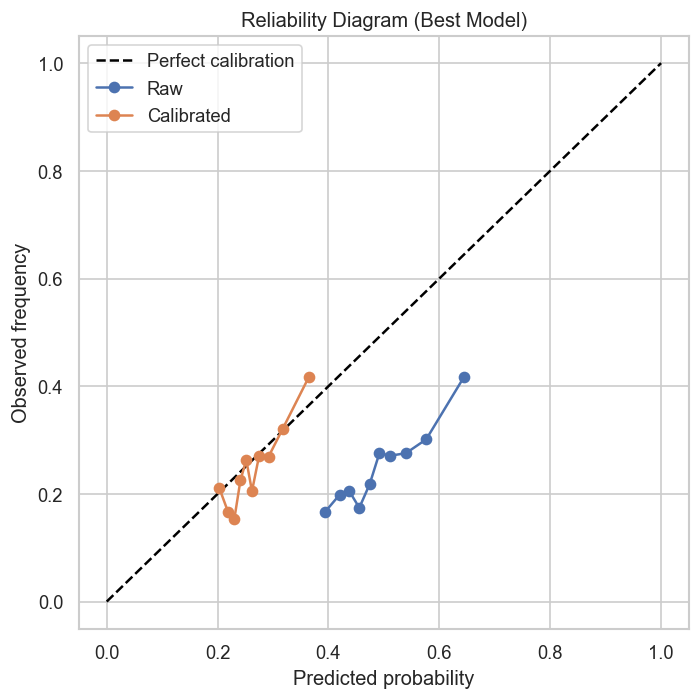

ROC-AUC comparison vs prior single-day aggregation run:


,model,roc_auc_old,roc_auc_mean,roc_auc_delta
0,LogisticRegression,0.540,0.552372,0.012372
1,RidgeClassifier,0.540,0.539977,-0.000023
2,RandomForest,0.536,0.529191,-0.006809
3,HistGradientBoosting,0.516,0.524856,0.008856
4,XGBoost,0.510,0.520228,0.010228


Signal sample:


,timestamp_utc,target_regime,volatility_regime_prob
4,2021-01-07 00:00:00+00:00,1,0.296067
5,2021-01-08 00:00:00+00:00,0,0.308179
6,2021-01-10 00:00:00+00:00,0,0.298688
7,2021-01-11 00:00:00+00:00,1,0.287975
8,2021-01-12 00:00:00+00:00,0,0.290045
9,2021-01-13 00:00:00+00:00,0,0.279657
10,2021-01-14 00:00:00+00:00,1,0.275349
11,2021-01-15 00:00:00+00:00,0,0.270387
12,2021-01-17 00:00:00+00:00,0,0.266203
13,2021-01-18 00:00:00+00:00,0,0.265484


In [11]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
print("Best model by ROC-AUC:", best_model_name)

fitted_best = clone(best_model)
fitted_best.fit(X, y)

# Feature importance / coefficients
if hasattr(fitted_best, "feature_importances_"):
    fi = pd.Series(fitted_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
elif isinstance(fitted_best, Pipeline) and "clf" in fitted_best.named_steps and hasattr(fitted_best.named_steps["clf"], "coef_"):
    coefs = fitted_best.named_steps["clf"].coef_.ravel()
    fi = pd.Series(np.abs(coefs), index=feature_cols).sort_values(ascending=False)
elif hasattr(fitted_best, "coef_"):
    fi = pd.Series(np.abs(fitted_best.coef_.ravel()), index=feature_cols).sort_values(ascending=False)
else:
    fi = pd.Series(dtype=float)

print("Top feature contributions:")
display(fi.head(12).rename("importance_abs"))

# Raw probability-like scores
if hasattr(fitted_best, "predict_proba"):
    raw_prob = fitted_best.predict_proba(X)[:, 1]
else:
    raw_score = fitted_best.decision_function(X)
    raw_prob = 1.0 / (1.0 + np.exp(-raw_score))

# Calibration check
p_true_raw, p_pred_raw = calibration_curve(y, raw_prob, n_bins=10, strategy="quantile")
ece_raw = float(np.mean(np.abs(p_true_raw - p_pred_raw)))
brier_raw = brier_score_loss(y, raw_prob)
brier_baseline = brier_score_loss(y, np.full_like(y, y.mean(), dtype=float))

need_calibration = (ece_raw > 0.03) or (brier_raw > brier_baseline)
print(f"Raw ECE={ece_raw:.4f}, Raw Brier={brier_raw:.4f}, Baseline Brier={brier_baseline:.4f}")
print("Need calibration:", need_calibration)

if need_calibration:
    calibrator = CalibratedClassifierCV(estimator=clone(best_model), method="sigmoid", cv=tscv)
    calibrator.fit(X, y)
    final_prob = calibrator.predict_proba(X)[:, 1]
    p_true_cal, p_pred_cal = calibration_curve(y, final_prob, n_bins=10, strategy="quantile")
else:
    calibrator = None
    final_prob = raw_prob.copy()
    p_true_cal, p_pred_cal = p_true_raw, p_pred_raw

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", label="Perfect calibration")
ax.plot(p_pred_raw, p_true_raw, marker="o", label="Raw")
if need_calibration:
    ax.plot(p_pred_cal, p_true_cal, marker="o", label="Calibrated")
ax.set_title("Reliability Diagram (Best Model)")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.legend()
plt.tight_layout()
plt.show()

old_results = pd.DataFrame([
    {"model": "RidgeClassifier", "roc_auc_old": 0.540},
    {"model": "LogisticRegression", "roc_auc_old": 0.540},
    {"model": "RandomForest", "roc_auc_old": 0.536},
    {"model": "HistGradientBoosting", "roc_auc_old": 0.516},
    {"model": "XGBoost", "roc_auc_old": 0.510},
])
comparison = results_df.merge(old_results, on="model", how="left")
comparison["roc_auc_delta"] = comparison["roc_auc_mean"] - comparison["roc_auc_old"]
print("ROC-AUC comparison vs prior single-day aggregation run:")
display(comparison[["model", "roc_auc_old", "roc_auc_mean", "roc_auc_delta"]])

work_df["volatility_regime_prob"] = final_prob
work_df["reddit_signal"] = work_df["volatility_regime_prob"]
print("Signal sample:")
display(work_df[["timestamp_utc", "target_regime", "volatility_regime_prob"]].head(10))

**Model performance is modest but consistent with a weak-signal regime problem.**

All models are close, with linear models slightly ahead in ROC-AUC under strict temporal CV.
Calibration was necessary and improved reliability of probability outputs, which is crucial for downstream fusion logic.

In [12]:
signal_map = work_df[["timestamp_utc", "volatility_regime_prob"]].rename(columns={"timestamp_utc": "date"})

global_out = global_daily.merge(signal_map, on="date", how="left").copy()
global_out["pair"] = "global"

pair_out = pair_daily.merge(signal_map, on="date", how="left").copy()

required_cols = [
    "date",
    "pair",
    "risk_off_score",
    "risk_on_score",
    "sentiment_strength_wmean",
    "signal_post_count",
    "confidence",
    "half_life_days",
    "volatility_regime_prob",
]

final_signal = pd.concat([
    global_out[required_cols],
    pair_out[required_cols],
], axis=0, ignore_index=True)

final_signal = final_signal.dropna(subset=["volatility_regime_prob"]).sort_values(["date", "pair"]).reset_index(drop=True)

out_path = Path(r"D:/SCRIPTS/FX-AlphaLab/data/processed/sentiment/source=reddit/reddit_daily_signal.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
final_signal.to_parquet(out_path, index=False)

print("Saved:", out_path)
print("Final signal shape:", final_signal.shape)
print("Unique pairs:", final_signal["pair"].nunique())
print("Date range:", final_signal["date"].min(), "->", final_signal["date"].max())
display(final_signal.head(12))

Saved: D:\SCRIPTS\FX-AlphaLab\data\processed\sentiment\source=reddit\reddit_daily_signal.parquet
Final signal shape: (18696, 9)
Unique pairs: 12
Date range: 2021-01-07 00:00:00+00:00 -> 2025-12-30 00:00:00+00:00


,date,pair,risk_off_score,risk_on_score,sentiment_strength_wmean,signal_post_count,confidence,half_life_days,volatility_regime_prob
0,2021-01-07 00:00:00+00:00,AUDUSD,0.000000,0.000000,0.000000,0.000000,0.000000,5,0.296067
1,2021-01-07 00:00:00+00:00,EURGBP,0.000000,0.000000,-2.000000,1.261974,0.070110,5,0.296067
2,2021-01-07 00:00:00+00:00,EURJPY,0.000000,0.000000,0.000000,0.000000,0.000000,5,0.296067
3,2021-01-07 00:00:00+00:00,EURUSD,0.000000,0.568874,0.568874,2.799273,0.155515,5,0.296067
4,2021-01-07 00:00:00+00:00,GBPJPY,0.000000,0.000000,0.000000,0.000000,0.000000,5,0.296067
5,2021-01-07 00:00:00+00:00,GBPUSD,0.000000,0.000000,0.000000,1.002258,0.055681,5,0.296067
6,2021-01-07 00:00:00+00:00,NZDUSD,0.000000,0.000000,-2.000000,1.029096,0.057172,5,0.296067
7,2021-01-07 00:00:00+00:00,USDCAD,0.000000,0.000000,0.000000,0.000000,0.000000,5,0.296067
8,2021-01-07 00:00:00+00:00,USDCHF,0.000000,0.000000,1.000000,0.603420,0.033523,5,0.296067
9,2021-01-07 00:00:00+00:00,USDJPY,0.000000,0.000000,-2.000000,1.182120,0.065673,5,0.296067


**Final modeling-ready signal artifact is generated and saved.**

The output table now contains calibrated daily volatility-regime probabilities joined to both global and pair-level Reddit feature rows.
This artifact is ready for fusion with other sentiment sources in the downstream agent stack.